In [1]:
import pandas as pd

In [2]:
from etna.datasets.tsdataset import TSDataset
from etna.transforms import (
    LogTransform,
    StandardScalerTransform,
    LinearTrendTransform,
    SegmentEncoderTransform,
    LagTransform,
    DateFlagsTransform,
    MeanTransform,
    MinMaxDifferenceTransform,
)
from etna.metrics import SMAPE, WAPE
from etna.models import CatBoostMultiSegmentModel, SeasonalMovingAverageModel
from etna.pipeline import Pipeline
from etna.analysis import plot_forecast

In [3]:
def train_and_evaluate_model(
    ts,
    model,
    transforms,
    horizon,
    metrics,
    print_metrics=False,
    print_plots=False,
    n_train_samples=None
):
    """
    Обучает модель, вычисляет прогнозы для
    тестовой выборки и строит график прогнозов.
    Параметры
    ----------
    ts: pandas.DataFrame
    Временной ряд.
    model: instance of class etna
    Экземпляр класса библиотеки etna.
    transforms: list
    Список преобразований.
    horizon: int
    Горизонт прогнозирования.
    metrics: instance of class etna.metrics.SMAPE/
    MAE/R2/MAPE/MedAE/MSLE
    Метрика качества.
    print_metrics: bool, по умолчанию False
    Печать метрик.
    print_plots: bool, по умолчанию False
    Печать графиков прогнозов.
    n_train_sample: int
    n последних наблюдений обучающей выборки
    на графике прогнозов.
    """
    if not print_plots and n_train_samples is not None:
        raise ValueError(
            "Параметр n_train_samples задается при print_plots=True"
        )
    # разбиваем набор на обучающую и тестовую выборки
    # с учетом временной структуры, размер тестовой
    # выборки задаем равным горизонту
    train_ts, test_ts = ts.train_test_split(test_size=horizon)
    # создаем конвейер
    pipe = Pipeline(
        model=model,
        transforms=transforms,
        horizon=horizon)
    
    # обучаем конвейер
    pipe.fit(train_ts)
    # получаем прогнозы
    forecast_ts = pipe.forecast()
    # оцениваем качество прогнозов по сегментам
    segment_metrics = metrics(test_ts, forecast_ts)
    segment_metrics = pd.Series(segment_metrics)
    
    if print_metrics:
        # print(segment_metrics.to_string())
        # print("")
        # оцениваем качество прогнозов в среднем
        print(f"WAPE:" f"{sum(segment_metrics) / len(segment_metrics)}")
    
    if print_plots:
        # визуализируем прогнозы, здесь n_train_samples
        # – n последних наблюдений в обучающей выборке
        plot_forecast(forecast_ts, test_ts,
        train_ts, n_train_samples=n_train_samples)

    return forecast_ts

# Data

In [61]:
regular_tours_df = pd.read_parquet('../../data/regular_tours/')
regular_tours_df.head()

,tour_id,first_tour_date,last_tour_date,days_between_first_and_last_tour_date,n_dates_with_sales,tickets,avg_tickets_per_day,days_with_sales_share,_start_date,_end_date,_created_ts
0,125624,2022-11-04,2026-04-30,1273,987,13851,14.03,0.78,2022-11-01,2026-05-01,2026-06-11 17:06:48.497
1,157275,2022-11-01,2026-04-30,1276,1236,16645,13.47,0.97,2022-11-01,2026-05-01,2026-06-11 17:06:48.497
2,267182,2023-04-29,2026-04-30,1097,412,7005,17.00,0.38,2022-11-01,2026-05-01,2026-06-11 17:06:48.497
3,400697,2022-11-01,2026-04-30,1276,758,19946,26.31,0.59,2022-11-01,2026-05-01,2026-06-11 17:06:48.497
4,30308,2022-11-27,2026-04-30,1250,771,9998,12.97,0.62,2022-11-01,2026-05-01,2026-06-11 17:06:48.497


In [62]:
regular_tours_df[regular_tours_df['tour_id'] == 888]

,tour_id,first_tour_date,last_tour_date,days_between_first_and_last_tour_date,n_dates_with_sales,tickets,avg_tickets_per_day,days_with_sales_share,_start_date,_end_date,_created_ts
3174,888,2022-11-01,2026-04-30,1276,95,1584,16.67,0.07,2022-11-01,2026-05-01,2026-06-11 17:06:48.497


In [63]:
regular_tours_df = regular_tours_df[regular_tours_df['days_with_sales_share'] > 0.4]

In [64]:
tour_date_ts_df = pd.read_parquet('../../data/tour_day_sales/')
tour_date_ts_df.head()

,tour_id,tour_date,tickets
0,980570,2026-03-27,22
1,194990,2026-04-01,17
2,695420,2026-03-28,9
3,798664,2026-04-14,13
4,138878,2026-03-23,18


In [65]:
analytics_forecast_df = pd.read_parquet('../../data/accuracy_snapshot/')
analytics_forecast_df['tour_date'] = analytics_forecast_df['tour_date'].astype(str)
analytics_forecast_df.head()

,forecast_created_date,tour_date,tour_id,forecast,tickets
0,2026-01-26,2026-04-14,2539,0.0,0
1,2026-01-26,2026-04-14,4581,0.0,0
2,2026-01-26,2026-04-14,6461,59.0,48
3,2026-01-26,2026-04-14,7691,0.0,0
4,2026-01-26,2026-04-14,10751,7.0,16


# Use only regular tours

In [66]:
tour_date_ts_df = tour_date_ts_df.merge(regular_tours_df[['tour_id']], on='tour_id', how='inner')
analytics_forecast_df = analytics_forecast_df.merge(regular_tours_df[['tour_id']], on='tour_id', how='inner')

In [67]:
tour_date_ts_df.shape

(2465161, 3)

In [68]:
analytics_forecast_df.shape

(199883, 5)

In [69]:
len(analytics_forecast_df['tour_id'].unique())

2528

In [70]:
len(tour_date_ts_df['tour_id'].unique())

2541

In [71]:
tour_date_ts_df = tour_date_ts_df.merge(
    analytics_forecast_df[['tour_id']].drop_duplicates(),
    on='tour_id', 
    how='inner',
)

In [72]:
len(tour_date_ts_df['tour_id'].unique())

2528

# Compare sales fact

In [73]:
analytics_forecast_df.rename({'tickets': 'analytics_tickets'})

tmp_df = tour_date_ts_df.merge(
    analytics_forecast_df.rename(columns={'tickets': 'analytics_tickets'}),
    on=['tour_id', 'tour_date'], 
    how='inner',
)

In [74]:
tmp_df.shape

(166244, 6)

In [75]:
tmp_df

,tour_id,tour_date,tickets,forecast_created_date,forecast,analytics_tickets
0,194990,2026-04-01,17,2026-01-26,21.0,17
1,108082,2026-04-28,60,2026-01-26,43.0,60
2,48586,2026-03-27,34,2026-01-26,40.0,34
3,428189,2026-03-23,19,2026-01-26,46.0,19
4,142833,2026-04-02,25,2026-01-26,44.0,25
...,...,...,...,...,...,...
166239,68335,2026-03-14,1,2026-01-26,4.0,1
166240,193403,2026-02-06,3,2026-01-26,25.0,3
166241,50028,2026-02-09,3,2026-01-26,2.0,3
166242,12879,2026-02-06,6,2026-01-26,4.0,6


In [76]:
mask = tmp_df['tickets'] != tmp_df['analytics_tickets']
print(sum(mask))
print(sum(mask) / len(mask))

2381
0.014322321407088376


# Modelling

In [77]:
tour_date_ts_df = tour_date_ts_df[tour_date_ts_df['tour_date'] < '2026-05-01'].reset_index(drop=True)

In [78]:
import numpy as np

In [79]:
rng = np.random.default_rng(seed=42)
tour_ids = np.random.choice(tour_date_ts_df['tour_id'].unique(), size=1000, replace=False)

In [80]:
print(len(tour_ids))

1000


In [81]:
# print(tour_ids)

In [82]:
# tour_ids = tour_date_ts_df['tour_id'].unique()[:500]
# print(tour_ids)

In [83]:
# tour_ids = [521, 528, 533, 576, 596, 603, 609, 613, 634, 655, 657, 679, 681, 691, 693, 722, 791, 945, 1021, 1061, 1103, 1177, 1225, 1251, 1307, 1329, 1361, 1745, 1753, 1781, 1871, 1879, 2501, 2901, 2907, 2951, 2987, 2991,
#   3205, 3285, 3287, 3393, 3399, 3455, 3479, 3513, 3667, 3669, 3673, 3823]

In [111]:
hist_sales = tour_date_ts_df

hist_sales = hist_sales[hist_sales['tour_id'].isin(tour_ids)]

hist_sales['date'] = pd.to_datetime(hist_sales['tour_date'])
hist_sales['tickets_sold'] = hist_sales['tickets']
hist_sales = hist_sales.set_index("date")

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/3196907311.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hist_sales['date'] = pd.to_datetime(hist_sales['tour_date'])
/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/3196907311.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hist_sales['tickets_sold'] = hist_sales['tickets']


In [112]:
hist_sales.shape

(944691, 4)

In [113]:
# tour_id = 194990
# tour_id = 108082

# tour_id = 415851
tour_id = 888

<Axes: xlabel='date'>

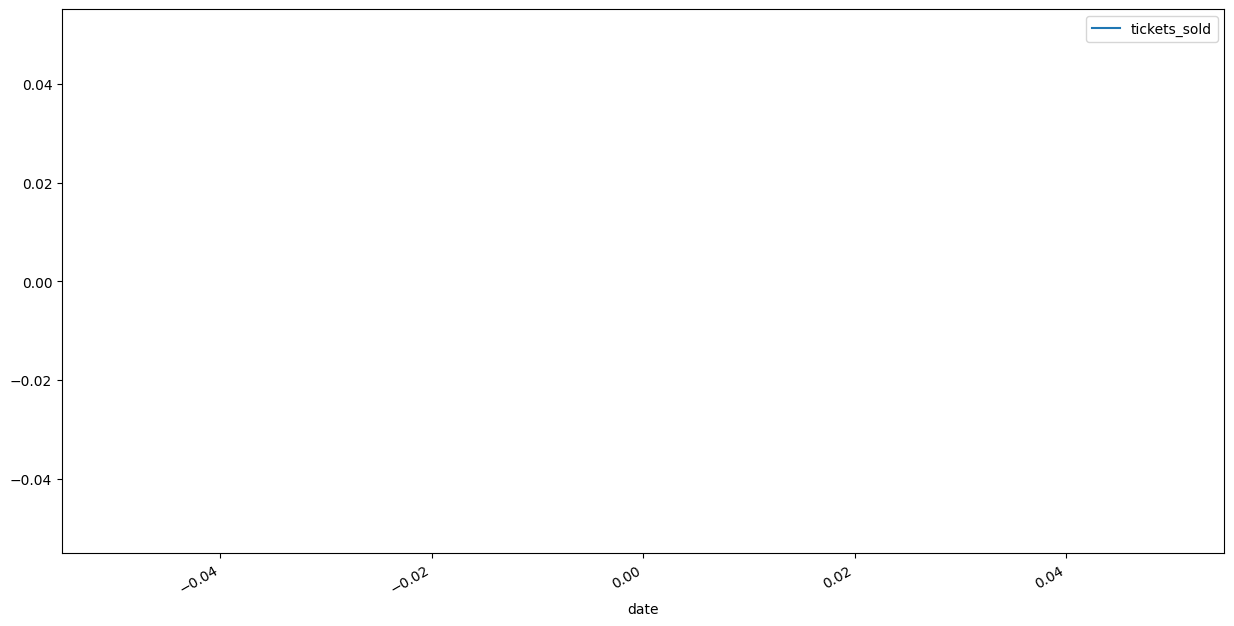

In [114]:
tmp_df = hist_sales[hist_sales['tour_id'] == tour_id]
tmp_df = tmp_df.sort_values('date')
tmp_df['tickets_sold'].plot(figsize=(15, 8), legend=True)

In [115]:
tmp_df

,tour_id,tour_date,tickets,tickets_sold
date,,,,


In [116]:
# s = hist_sales[hist_sales['tour_id'] == tid][['tickets_sold']].sort_index()
# full_range = pd.date_range(s.index.min(), s.index.max(), freq='D')

In [117]:
# full_range

In [118]:
# s.index[0]

In [119]:
# full_range[2]

In [120]:
# s = s.reindex(full_range)

In [121]:
# s

In [122]:
# Fill missing dates per tour_id with linear interpolation
filled = []
for tid in hist_sales['tour_id'].unique():
    s = hist_sales[hist_sales['tour_id'] == tid][['tickets_sold']].sort_index()
    full_range = pd.date_range(s.index.min(), s.index.max(), freq='D')
    s = s.reindex(full_range)
    s['tickets_sold'] = s['tickets_sold'].interpolate(method='linear')
    s['tour_id'] = tid
    filled.append(s)

hist_sales = pd.concat(filled)
hist_sales.index.name = 'date'
print(hist_sales.shape)

(1195280, 2)


In [123]:
sum(hist_sales['tickets_sold'] > 0 )

1195280

In [124]:
tour_id = 415851

<Axes: xlabel='date'>

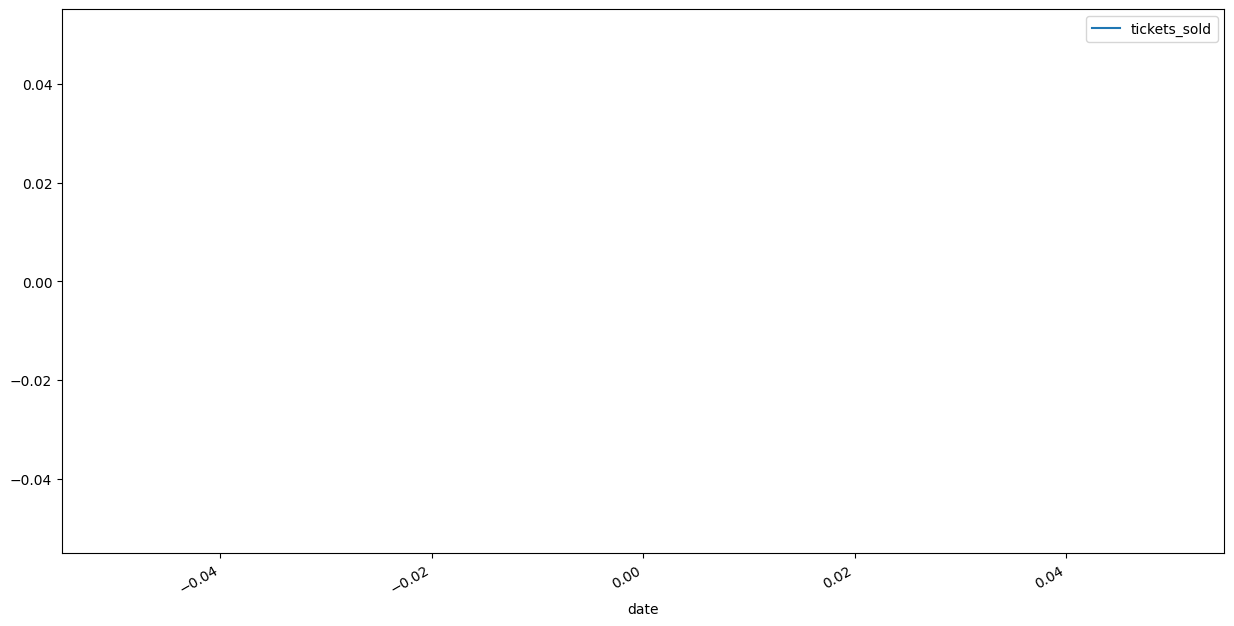

In [125]:
hist_sales[hist_sales['tour_id'] == tour_id]['tickets_sold'].plot(figsize=(15, 8), legend=True)

In [126]:
hist_sales['timestamp'] = hist_sales.index
hist_sales = hist_sales.reset_index(drop=True)

In [127]:
hist_sales_melt = hist_sales.rename(columns={'tickets_sold': 'target', 'tour_id': 'segment'})

In [128]:
# создаем переменную – квартал, начало и конец квартала
hist_sales_melt['quarter'] = hist_sales_melt['timestamp'].dt.quarter
hist_sales_melt['quarter_start'] = hist_sales_melt['timestamp'].dt.is_quarter_start
hist_sales_melt['quarter_end'] = hist_sales_melt['timestamp'].dt.is_quarter_end
# создаем переменную – название месяца
hist_sales_melt['month_name'] = hist_sales_melt['timestamp'].dt.strftime('%b')
hist_sales_melt['month_name'] = hist_sales_melt['month_name'].astype('category')
hist_sales_melt.head()

,target,segment,timestamp,quarter,quarter_start,quarter_end,month_name
0,47.0,108082,2023-01-01,1,True,False,Jan
1,19.0,108082,2023-01-02,1,False,False,Jan
2,21.0,108082,2023-01-03,1,False,False,Jan
3,5.0,108082,2023-01-04,1,False,False,Jan
4,10.0,108082,2023-01-05,1,False,False,Jan


In [129]:
# переводим набор данных о продажах в формат ETNA
df_ts_format = TSDataset.to_dataset(hist_sales_melt)

In [130]:
ts = TSDataset(
    df_ts_format, 
    freq='D',
    # df_exog=df_regressors_ts_format, 
    known_future='all',
)

In [131]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
100467,2023-01-02,2026-04-30,1215,0,1000,4,0,0,D
100854,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
100938,2023-03-03,2026-04-30,1155,0,1000,4,0,0,D
1021,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
102233,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
...,...,...,...,...,...,...,...,...,...
98181,2023-03-25,2026-04-30,1133,0,1000,4,0,0,D
99024,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
99036,2023-01-02,2026-04-30,1215,0,1000,4,0,0,D


In [132]:
summary_table = ts.describe()

In [133]:
summary_table

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
100467,2023-01-02,2026-04-30,1215,0,1000,4,0,0,D
100854,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
100938,2023-03-03,2026-04-30,1155,0,1000,4,0,0,D
1021,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
102233,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
...,...,...,...,...,...,...,...,...,...
98181,2023-03-25,2026-04-30,1133,0,1000,4,0,0,D
99024,2023-01-01,2026-04-30,1216,0,1000,4,0,0,D
99036,2023-01-02,2026-04-30,1215,0,1000,4,0,0,D


In [134]:
sum(summary_table['end_timestamp'] != '2026-04-30')

0

In [135]:
print(summary_table[["start_timestamp", "end_timestamp", "length"]].sort_values("length").head(20))

         start_timestamp end_timestamp  length
segments                                      
4503          2023-05-31    2026-04-30    1066
167798        2023-05-01    2026-04-30    1096
430497        2023-05-01    2026-04-30    1096
252107        2023-05-01    2026-04-30    1096
365545        2023-05-01    2026-04-30    1096
412548        2023-04-30    2026-04-30    1097
113011        2023-04-29    2026-04-30    1098
447011        2023-04-29    2026-04-30    1098
266722        2023-04-29    2026-04-30    1098
24634         2023-04-27    2026-04-30    1100
438836        2023-04-27    2026-04-30    1100
68071         2023-04-27    2026-04-30    1100
33967         2023-04-25    2026-04-30    1102
441473        2023-04-23    2026-04-30    1104
449567        2023-04-23    2026-04-30    1104
396090        2023-04-23    2026-04-30    1104
447252        2023-04-22    2026-04-30    1105
454886        2023-04-22    2026-04-30    1105
433654        2023-04-22    2026-04-30    1105
459243       

In [136]:
clean_tour_ids = summary_table[summary_table['num_missing'] == 0].index

In [137]:
clean_tour_ids = [int(tour_id) for tour_id in list(clean_tour_ids)]
print(len(clean_tour_ids))

870


In [138]:
hist_sales

,tickets_sold,tour_id,timestamp
0,47.0,108082,2023-01-01
1,19.0,108082,2023-01-02
2,21.0,108082,2023-01-03
3,5.0,108082,2023-01-04
4,10.0,108082,2023-01-05
...,...,...,...
1195275,8.0,448835,2026-04-26
1195276,15.0,448835,2026-04-27
1195277,8.0,448835,2026-04-28
1195278,5.0,448835,2026-04-29


In [139]:
hist_sales = hist_sales[hist_sales['tour_id'].isin(clean_tour_ids)]

In [140]:
hist_sales_melt = hist_sales.rename(columns={'tickets_sold': 'target', 'tour_id': 'segment'})
# создаем переменную – квартал, начало и конец квартала
hist_sales_melt['quarter'] = hist_sales_melt['timestamp'].dt.quarter
hist_sales_melt['quarter_start'] = hist_sales_melt['timestamp'].dt.is_quarter_start
hist_sales_melt['quarter_end'] = hist_sales_melt['timestamp'].dt.is_quarter_end
# создаем переменную – название месяца
hist_sales_melt['month_name'] = hist_sales_melt['timestamp'].dt.strftime('%b')
hist_sales_melt['month_name'] = hist_sales_melt['month_name'].astype('category')
hist_sales_melt.head()
# переводим набор данных о продажах в формат ETNA
df_ts_format = TSDataset.to_dataset(hist_sales_melt)
ts = TSDataset(
    df_ts_format, 
    freq='D',
    # df_exog=df_regressors_ts_format, 
    known_future='all',
)

In [141]:
summary_table = ts.describe()
len(summary_table[summary_table['num_missing'] != 0])

0

In [142]:
tour_id = 415851

<Axes: >

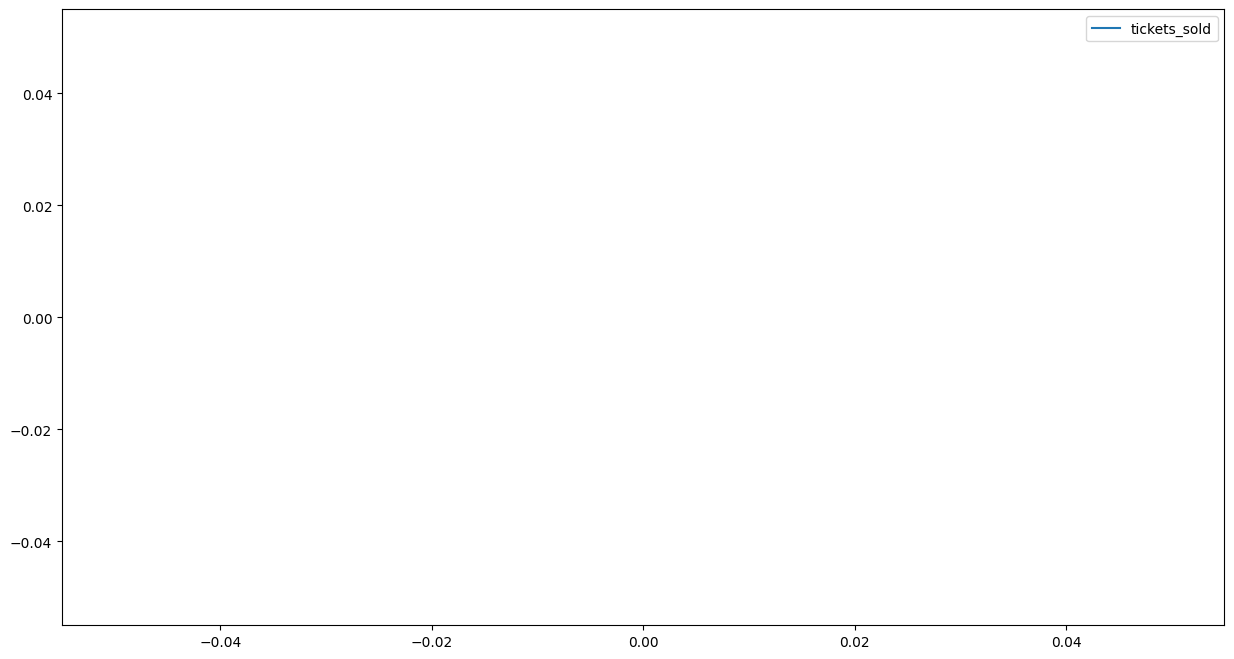

In [143]:
hist_sales[hist_sales['tour_id'] == tour_id]['tickets_sold'].plot(figsize=(15, 8), legend=True)

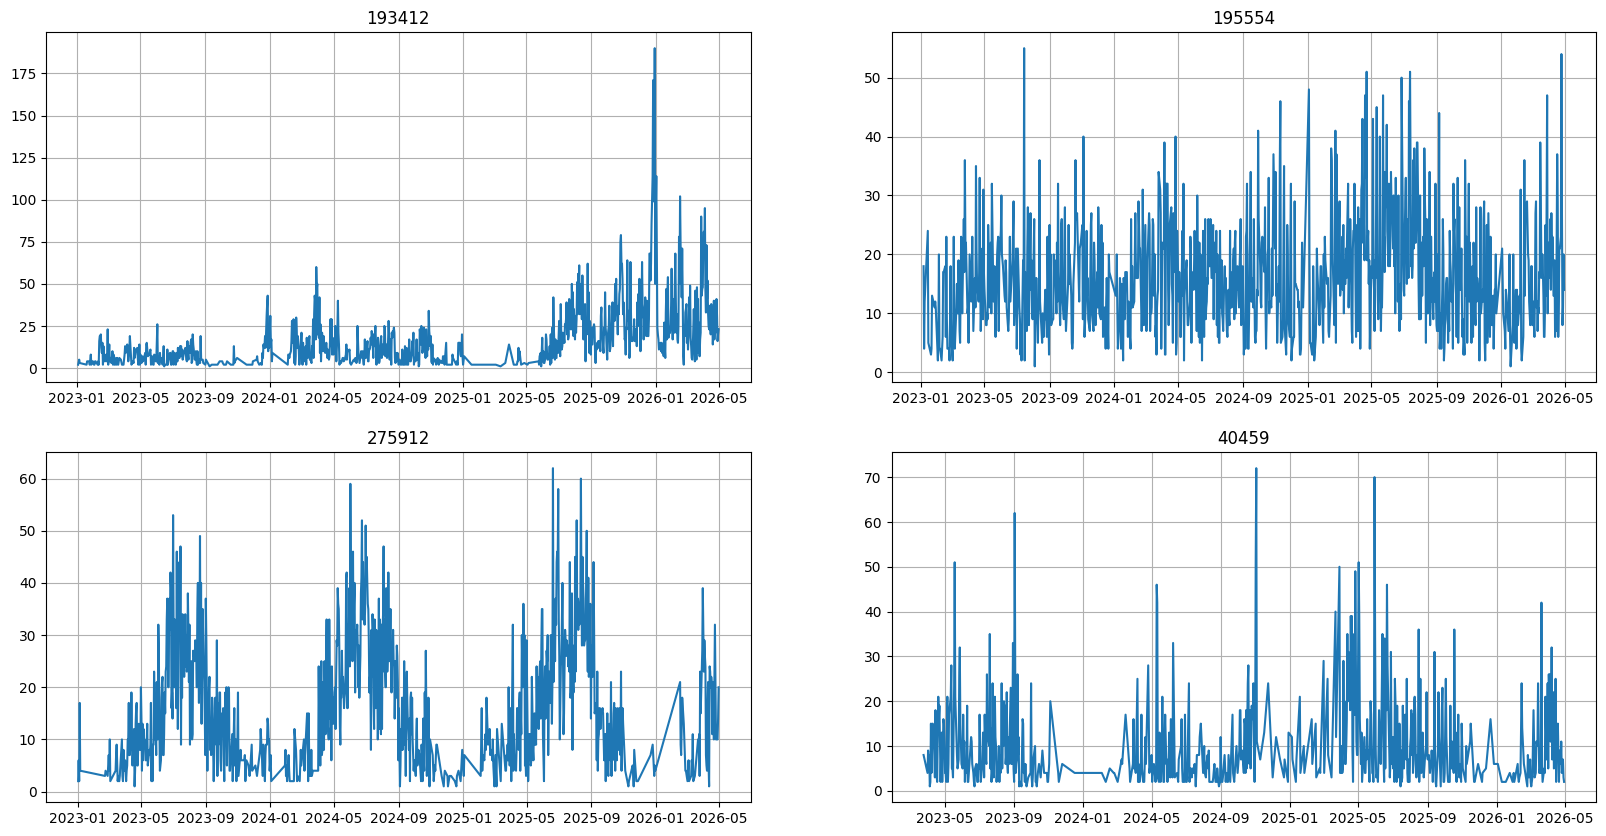

In [144]:
ts.plot(4)

In [145]:
log = LogTransform(in_column='target')
scaler = StandardScalerTransform(in_column='target')
detrend = LinearTrendTransform(in_column='target')
seg = SegmentEncoderTransform()
lags = LagTransform(
    in_column='target',
    lags=list(range(90, 361, 30)),
    out_column='lag'
)
lags_2 = LagTransform(
    in_column='target',
    lags=[364, 365],
    out_column='lag'
)
d_flags = DateFlagsTransform(day_number_in_year=True,
    day_number_in_week=True,
    day_number_in_month=True,
    week_number_in_month=True,
    week_number_in_year=True,
    month_number_in_year=True,
    season_number=True,
    is_weekend=True,
    out_column='datetime'
)
mean90 = MeanTransform(in_column='target', window=90,
    out_column='mean90')
mean180 = MeanTransform(in_column='target', window=180,
    out_column='mean180')
mean270 = MeanTransform(in_column='target', window=270,
    out_column='mean270')

minmax270 = MinMaxDifferenceTransform(
    in_column='target', 
    window=270,
    out_column='minmax270',
)

In [146]:
# задаем горизонт прогнозирования
HORIZON = 90

In [147]:
wape = WAPE()

In [148]:
ctbst_model = CatBoostMultiSegmentModel(
    iterations=500,
    learning_rate=0.25,
    depth=5,
)

In [149]:
preprocess = [
    log, scaler, seg, lags, lags_2, d_flags,
    mean90, mean180, mean270, minmax270
]

In [150]:
forecast_ctbst = train_and_evaluate_model(
    ts=ts,
    model=ctbst_model,
    transforms=preprocess,
    horizon=HORIZON,
    metrics=wape,
    print_metrics=True,
    # print_plots=True,
    # n_train_samples=180
)

/Users/sergey.rubtsovenko/Projects/research/.venv/lib/python3.12/site-packages/etna/datasets/utils.py:190: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long["segment"] = np.repeat(a=segments, repeats=n_timestamps)
/Users/sergey.rubtsovenko/Projects/research/.venv/lib/python3.12/site-packages/etna/transforms/math/statistics.py:94: RuntimeWarning: invalid value encountered in multiply
  x = np.append(x, np.empty((history - 1, x.shape[1])) * np.nan, axis=0)
/Users/sergey.rubtsovenko/Projects/research/.venv/lib/python3.12/site-packages/etna/datasets/utils.py:190: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

WAPE:0.6404586970481693


In [151]:
naive_model = SeasonalMovingAverageModel(window=1, seasonality=364)

forecast_seasonal = train_and_evaluate_model(
    ts=ts,
    model=naive_model,
    transforms=[],
    horizon=HORIZON,
    metrics=wape,
    print_metrics=True,
    # print_plots=True,
    # n_train_samples=180
)

/Users/sergey.rubtsovenko/Projects/research/.venv/lib/python3.12/site-packages/etna/models/seasonal_ma.py:64: UserWarning: This model doesn't work with exogenous features. Columns {'month_name', 'quarter_start', 'quarter_end', 'quarter'} won't be used.
  warnings.warn(


WAPE:0.8149355522725461


In [390]:
forecast_ctbst

segment                          100938                              \
feature    datetime_day_number_in_month datetime_day_number_in_week   
timestamp                                                             
2026-01-31                           31                           5   
2026-02-01                            1                           6   
2026-02-02                            2                           0   
2026-02-03                            3                           1   
2026-02-04                            4                           2   
...                                 ...                         ...   
2026-04-26                           26                           6   
2026-04-27                           27                           0   
2026-04-28                           28                           1   
2026-04-29                           29                           2   
2026-04-30                           30                           3   

segment                                                     \
feature    datetime_day_number_in_year datetime_is_weekend   
timestamp                                                    
2026-01-31                          31                True   
2026-02-01                          32                True   
2026-02-02                          33               False   
2026-02-03                          34               False   
2026-02-04                          35               False   
...                                ...                 ...   
2026-04-26                         117                True   
2026-04-27                         118               False   
2026-04-28                         119               False   
2026-04-29                         120               False   
2026-04-30                         121               False   

segment                                                          \
feature    datetime_month_number_in_year datetime_season_number   
timestamp                                                         
2026-01-31                             1                      1   
2026-02-01                             2                      1   
2026-02-02                             2                      1   
2026-02-03                             2                      1   
2026-02-04                             2                      1   
...                                  ...                    ...   
2026-04-26                             4                      2   
2026-04-27                             4                      2   
2026-04-28                             4                      2   
2026-04-29                             4                      2   
2026-04-30                             4                      2   

segment                                                                \
feature    datetime_week_number_in_month datetime_week_number_in_year   
timestamp                                                               
2026-01-31                             5                            5   
2026-02-01                             1                            5   
2026-02-02                             2                            6   
2026-02-03                             2                            6   
2026-02-04                             2                            6   
...                                  ...                          ...   
2026-04-26                             4                           17   
2026-04-27                             5                           18   
2026-04-28                             5                           18   
2026-04-29                             5                           18   
2026-04-30                             5                           18   

segment                         ...     98226                                \
feature      lag_120   lag_150  ...   mean180   mean270    mean90 minmax270   
timestamp       

In [391]:
df = forecast_ctbst.to_pandas(flatten=False)

In [392]:
df.columns

MultiIndex([('100938',  'datetime_day_number_in_month'),
            ('100938',   'datetime_day_number_in_week'),
            ('100938',   'datetime_day_number_in_year'),
            ('100938',           'datetime_is_weekend'),
            ('100938', 'datetime_month_number_in_year'),
            ('100938',        'datetime_season_number'),
            ('100938', 'datetime_week_number_in_month'),
            ('100938',  'datetime_week_number_in_year'),
            ('100938',                       'lag_120'),
            ('100938',                       'lag_150'),
            ...
            ( '98226',                       'mean180'),
            ( '98226',                       'mean270'),
            ( '98226',                        'mean90'),
            ( '98226',                     'minmax270'),
            ( '98226',                    'month_name'),
            ( '98226',                       'quarter'),
            ( '98226',                   'quarter_end'),
            ( '

In [393]:
len(forecast_ctbst.segments)

302

In [394]:
len(forecast_ctbst.segments) * 90

27180

In [395]:
df.stack(level="segment").reset_index().shape

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_12636/883654457.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack(level="segment").reset_index().shape


(27180, 32)

In [396]:
df.stack(level="segment").reset_index()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_12636/2593984211.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.stack(level="segment").reset_index()


feature,timestamp,segment,datetime_day_number_in_month,datetime_day_number_in_week,datetime_day_number_in_year,datetime_is_weekend,datetime_month_number_in_year,datetime_season_number,datetime_week_number_in_month,datetime_week_number_in_year,...,mean180,mean270,mean90,minmax270,month_name,quarter,quarter_end,quarter_start,segment_code,target
0,2026-01-31,100938,31,5,31,True,1,1,5,5,...,0.151608,0.508447,-0.809766,3.820587,NaN,NaN,NaN,NaN,0,15.024292
1,2026-01-31,103862,31,5,31,True,1,1,5,5,...,-0.592216,-0.458067,-0.954775,5.204737,NaN,NaN,NaN,NaN,1,5.355627
2,2026-01-31,108793,31,5,31,True,1,1,5,5,...,-0.080604,0.182603,-0.743350,4.008485,NaN,NaN,NaN,NaN,2,6.765879
3,2026-01-31,108973,31,5,31,True,1,1,5,5,...,0.028197,0.282983,-0.811210,3.938180,NaN,NaN,NaN,NaN,3,6.244775
4,2026-01-31,1103,31,5,31,True,1,1,5,5,...,-0.391713,-0.448210,-0.203374,7.717526,NaN,NaN,NaN,NaN,4,201.098089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27175,2026-04-30,947,30,3,121,False,4,2,5,18,...,0.506559,0.682562,0.000000,3.072365,NaN,NaN,NaN,NaN,297,6.464649
27176,2026-04-30,96594,30,3,121,False,4,2,5,18,...,0.099878,0.335501,0.000000,4.260347,NaN,NaN,NaN,NaN,298,72.005532
27177,2026-04-30,97437,30,3,121,False,4,2,5,18,...,-0.193639,0.541652,0.000000,4.427195,NaN,NaN,NaN,NaN,299,34.639990
27178,2026-04-30,98181,30,3,121,False,4,2,5,18,...,0.350997,0.046368,0.000000,3.606928,NaN,NaN,NaN,NaN,300,16.205098


In [318]:
  df_filtered = df.loc[:, df.columns.get_level_values("segment").isin([99348])]

In [322]:
df.reset_index().reset_index()

segment index  timestamp                       102566  \
feature                  datetime_day_number_in_month   
0           0 2026-03-03                            3   
1           1 2026-03-04                            4   
2           2 2026-03-05                            5   
3           3 2026-03-06                            6   
4           4 2026-03-07                            7   
..        ...        ...                          ...   
85         85 2026-05-27                           27   
86         86 2026-05-28                           28   
87         87 2026-05-29                           29   
88         88 2026-05-30                           30   
89         89 2026-05-31                           31   

segment                                                          \
feature datetime_day_number_in_week datetime_day_number_in_year   
0                                 1                          63   
1                                 2                          64   
2                                 3                          65   
3                                 4                          66   
4                                 5                          67   
..                              ...                         ...   
85                                2                         148   
86                                3                         149   
87                                4                         150   
88                                5                         151   
89                                6                         152   

segment                                                    \
feature datetime_is_weekend datetime_month_number_in_year   
0                     False                             3   
1                     False                             3   
2                     False                             3   
3                     False                             3   
4                      True                             3   
..                      ...                           ...   
85                    False                             5   
86                    False                             5   
87                    False                             5   
88                     True                             5   
89                     True                             5   

segment                                                       \
feature datetime_season_number datetime_week_number_in_month   
0                            2                             2   
1                            2                             2   
2                            2                             2   
3                            2                             2   
4                            2                             2   
..                         ...                           ...   
85                           2                             5   
86                           2                             5   
87                           2                             5   
88                           2                             5   
89                           2                             5   

segment                               ...     99348                      \
feature datetime_week_number_in_year  ...   mean180   mean270    mean90   
0                                 10  ... -0.201855  0.256476 -0.350020   
1                                 10  ... -0.204959  0.254374 -0.331158   
2                                 10  ... -0.211490  0.251955 -0.321356   
3                                 10  ... -0.218095  0.252249 -0.325342   
4                                 10  ... -0.220858  0.248609 -0.330044   
..                               ...  ...       ...       ...       ...   
85                                22  ... -0.393026 -0.179747  0.183168   
86                                22  ... -0.401876 -0.182645  0.550245   
87       

In [316]:
df_filtered

timestamp
2026-03-03
2026-03-04
2026-03-05
2026-03-06
2026-03-07
...
2026-05-27
2026-05-28
2026-05-29
2026-05-30


In [307]:
naive_model = SeasonalMovingAverageModel(window=1, seasonality=364)

forecast_seasonal = train_and_evaluate_model(
    ts=ts,
    model=naive_model,
    transforms=[],
    horizon=HORIZON,
    metrics=wape,
    print_metrics=True,
    # print_plots=True,
    # n_train_samples=180
)

/Users/sergey.rubtsovenko/Projects/research/.venv/lib/python3.12/site-packages/etna/models/seasonal_ma.py:64: UserWarning: This model doesn't work with exogenous features. Columns {'month_name', 'quarter_end', 'quarter_start', 'quarter'} won't be used.
  warnings.warn(


ValueError: There are NaNs in a forecast context, forecast method requires context to be filled!

# Comparison with analytics forecast

In [206]:
df = forecast_ctbst.to_pandas(flatten=False)
df = df.stack(level="segment").reset_index()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/1751950966.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack(level="segment").reset_index()


In [207]:
df = df.rename(columns={'timestamp': 'tour_date', 'segment': 'tour_id'})[['tour_id', 'tour_date', 'target']]
df.columns.name = None

df['tour_id'] = df['tour_id'].astype(int)
df['tour_date'] = df['tour_date'].astype(str)

In [208]:
df

,tour_id,tour_date,target
0,100467,2026-01-31,10.776784
1,100854,2026-01-31,9.260673
2,100938,2026-01-31,34.460613
3,1021,2026-01-31,15.854967
4,102233,2026-01-31,18.201499
...,...,...,...
78295,98181,2026-04-30,12.318161
78296,99024,2026-04-30,25.490218
78297,99036,2026-04-30,25.110787
78298,99081,2026-04-30,11.574648


In [185]:
df['tour_date'].min()

'2026-01-31'

In [186]:
df['tour_date'].max()

'2026-04-30'

In [295]:
analytics_forecast_selected_df = analytics_forecast_df.merge(df, on=['tour_id', 'tour_date'], how='inner')

In [296]:
analytics_forecast_selected_df.shape

(69497, 6)

In [297]:
analytics_forecast_selected_df

,forecast_created_date,tour_date,tour_id,forecast,tickets,target
0,2026-01-26,2026-04-14,25877,46.0,16,10.775110
1,2026-01-26,2026-04-14,65712,10.0,17,22.757344
2,2026-01-26,2026-04-14,66660,57.0,22,23.923166
3,2026-01-26,2026-04-14,85922,22.0,18,21.333439
4,2026-01-26,2026-04-14,102239,16.0,14,5.922369
...,...,...,...,...,...,...
69492,2026-01-26,2026-02-02,393467,6.0,10,7.425192
69493,2026-01-26,2026-02-02,425460,5.0,0,6.431096
69494,2026-01-26,2026-02-02,30360,5.0,0,9.604173
69495,2026-01-26,2026-02-02,137729,34.0,14,16.295839


In [298]:
df_grouped = (
    analytics_forecast_selected_df
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets'] - group['forecast']).abs().sum(),
        'fact_sum': group['tickets'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/466385174.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


1.068904477329043

In [299]:
df_grouped = (
    analytics_forecast_selected_df
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets'] - group['target']).abs().sum(),
        'fact_sum': group['tickets'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2853266869.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.9313318693728597

In [300]:
wape(analytics_forecast_selected_df["tickets"], analytics_forecast_selected_df["forecast"])

0.6706469392959084

In [301]:
wape(analytics_forecast_selected_df["tickets"], analytics_forecast_selected_df["target"])

0.5579573118095762

In [209]:
pred_with_target = df.merge(tour_date_ts_df[['tour_id', 'tour_date', 'tickets']], on=['tour_id', 'tour_date'], how='inner')

In [212]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets'] - group['target']).abs().sum(),
        'fact_sum': group['tickets'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/1390162471.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.64613187167218

In [231]:
analytics_forecast_selected_df

,forecast_created_date,tour_date,tour_id,forecast,tickets,target
0,2026-01-26,2026-04-14,25877,46.0,16,10.775110
1,2026-01-26,2026-04-14,65712,10.0,17,22.757344
2,2026-01-26,2026-04-14,66660,57.0,22,23.923166
3,2026-01-26,2026-04-14,85922,22.0,18,21.333439
4,2026-01-26,2026-04-14,102239,16.0,14,5.922369
...,...,...,...,...,...,...
69492,2026-01-26,2026-02-02,393467,6.0,10,7.425192
69493,2026-01-26,2026-02-02,425460,5.0,0,6.431096
69494,2026-01-26,2026-02-02,30360,5.0,0,9.604173
69495,2026-01-26,2026-02-02,137729,34.0,14,16.295839


In [302]:
pred_with_target = df.merge(tour_date_ts_df[['tour_id', 'tour_date', 'tickets']], on=['tour_id', 'tour_date'], how='inner')
print(pred_with_target.shape)
pred_with_target = pred_with_target.merge(analytics_forecast_selected_df[['tour_id', 'tour_date', 'forecast', 'tickets']], on=['tour_id', 'tour_date'], how='inner')
print(pred_with_target.shape)

(61881, 4)
(61262, 6)


In [303]:
pred_with_target

,tour_id,tour_date,target,tickets_x,forecast,tickets_y
0,100854,2026-02-01,4.574385,3,14.0,3
1,102233,2026-02-01,14.292487,38,25.0,38
2,102239,2026-02-01,7.841894,1,0.0,1
3,103928,2026-02-01,16.475796,6,7.0,6
4,10505,2026-02-01,17.083433,26,18.0,26
...,...,...,...,...,...,...
61257,98181,2026-04-30,12.318161,11,0.0,11
61258,99024,2026-04-30,25.490218,45,17.0,45
61259,99036,2026-04-30,25.110787,20,15.0,20
61260,99081,2026-04-30,11.574648,3,4.0,3


In [304]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_x'] - group['forecast']).abs().sum(),
        'fact_sum': group['tickets_x'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/1424183560.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.8696085106423214

In [305]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_x'] - group['target']).abs().sum(),
        'fact_sum': group['tickets_x'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/953117398.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.6471883840359764

In [306]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_y'] - group['forecast']).abs().sum(),
        'fact_sum': group['tickets_y'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2377881812.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.8682494119883387

In [307]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_y'] - group['target']).abs().sum(),
        'fact_sum': group['tickets_y'].sum()
    }))
)
df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/86548184.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


0.646374483126138

In [308]:
def wape(actual, forecast):
      return (actual - forecast).abs().sum() / actual.sum()

In [309]:
wape(pred_with_target["tickets_x"], pred_with_target["forecast"])

0.6365942222750951

In [310]:
wape(pred_with_target["tickets_x"], pred_with_target["target"])

0.5129181047854457

In [311]:
pred_with_target["month"] = pd.to_datetime(df["tour_date"]).dt.month

In [315]:
pred_with_target.groupby("month").apply(lambda x: wape(x["tickets_x"], x["forecast"]))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/852858821.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_with_target.groupby("month").apply(lambda x: wape(x["tickets_x"], x["forecast"]))


month
1    0.458932
2    0.507626
3    0.747040
4    0.634712
dtype: float64

In [316]:
pred_with_target.groupby("month").apply(lambda x: wape(x["tickets_x"], x["target"]))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/1462502685.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_with_target.groupby("month").apply(lambda x: wape(x["tickets_x"], x["target"]))


month
1    0.463163
2    0.489487
3    0.530362
4    0.522701
dtype: float64

In [293]:
pred_with_target.groupby("tour_id").apply(lambda x: wape(x["tickets_x"], x["forecast"])).mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2108095331.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_with_target.groupby("tour_id").apply(lambda x: wape(x["tickets_x"], x["forecast"])).mean()


0.8696085106423214

In [314]:
pred_with_target.groupby("tour_id").apply(lambda x: wape(x["tickets_x"], x["target"]))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2622272675.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_with_target.groupby("tour_id").apply(lambda x: wape(x["tickets_x"], x["target"]))


tour_id
347       0.574002
533       0.517791
596       0.494904
609       1.806802
619       0.773951
            ...   
455967    0.378734
456291    0.515956
457265    0.397885
458561    0.891506
459243    0.628986
Length: 870, dtype: float64

In [284]:
df_grouped

,tour_id,abs_diff,fact_sum,wape
0,347,248.820986,432.0,0.575975
1,533,591.459408,1154.0,0.512530
2,596,576.563635,1165.0,0.494904
3,609,5116.864363,2832.0,1.806802
4,619,1355.188548,1751.0,0.773951
...,...,...,...,...
865,455967,1683.849711,4454.0,0.378053
866,456291,865.838538,1684.0,0.514156
867,457265,904.115032,2327.0,0.388532
868,458561,1919.210411,2149.0,0.893071


In [255]:
pred_with_target

,tour_id,tour_date,target,tickets_x,forecast,tickets_y,month
0,100854,2026-02-01,4.574385,3,14.0,3,1
1,102233,2026-02-01,14.292487,38,25.0,38,1
2,102239,2026-02-01,7.841894,1,0.0,1,1
3,103928,2026-02-01,16.475796,6,7.0,6,1
4,10505,2026-02-01,17.083433,26,18.0,26,1
...,...,...,...,...,...,...,...
61257,98181,2026-04-30,12.318161,11,0.0,11,4
61258,99024,2026-04-30,25.490218,45,17.0,45,4
61259,99036,2026-04-30,25.110787,20,15.0,20,4
61260,99081,2026-04-30,11.574648,3,4.0,3,4


In [256]:
pred_with_target["month"] = pd.to_datetime(df["tour_date"]).dt.month

In [285]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id', 'month'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_y'] - group['forecast']).abs().sum(),
        'fact_sum': group['tickets_y'].sum()
    }))
)
# df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
# df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2407666780.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


In [286]:
df_grouped

,tour_id,month,abs_diff,fact_sum
0,347,2,51.0,148.0
1,347,3,126.0,214.0
2,347,4,41.0,70.0
3,533,1,4.0,4.0
4,533,2,228.0,371.0
...,...,...,...,...
3090,458561,3,1791.0,1791.0
3091,458561,4,141.0,141.0
3092,459243,2,72.0,133.0
3093,459243,3,1004.0,741.0


In [ ]:
df_grouped['

In [287]:
df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({
    'wape': np.mean(group['abs_diff'] / group['fact_sum'])
}))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2539311200.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({


,month,wape
0,1,0.960366
1,2,0.741007
2,3,1.311305
3,4,1.084807


In [288]:
df_grouped = (
    pred_with_target
    .groupby(['tour_id', 'month'], as_index=False)
    .apply(lambda group: pd.Series({
        'abs_diff': (group['tickets_y'] - group['target']).abs().sum(),
        'fact_sum': group['tickets_y'].sum()
    }))
)
# df_grouped['wape'] = df_grouped['abs_diff'] / df_grouped['fact_sum']
# df_grouped['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/1161226152.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


In [289]:
df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({
    'wape': np.mean(group['abs_diff'] / group['fact_sum'])
}))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/2539311200.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({


,month,wape
0,1,0.875049
1,2,0.676476
2,3,0.871552
3,4,0.880207


In [279]:
tmp_df = df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({
    'wape': np.mean(group['abs_diff'] / group['fact_sum']),
    'n_recores': len(group),
    'actuals': sum(group['fact_sum']),
    'abs_diff': sum(group['abs_diff']),
}))

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/4096206606.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = df_grouped.groupby(['month'], as_index=False).apply(lambda group: pd.Series({


In [280]:
tmp_df

,month,wape,n_recores,actuals,abs_diff
0,1,0.875049,578.0,30325.0,14019.545440
1,2,0.676476,785.0,1053693.0,514993.902648
2,3,0.871552,862.0,1283828.0,680462.702046
3,4,0.880207,870.0,384691.0,201052.220225


In [281]:
tmp_df['abs_diff'].sum() / tmp_df['actuals'].sum()

0.512446652073772

In [266]:
tmp_df = df_grouped[df_grouped['month'] == 4]

In [267]:
tmp_df['wape'] = tmp_df['abs_diff'] / tmp_df['fact_sum']
tmp_df['wape'].mean()

/var/folders/17/fpk03l2j4734d5n7zr5fllf40000gp/T/ipykernel_17337/322993922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df['wape'] = tmp_df['abs_diff'] / tmp_df['fact_sum']


0.8802073600048778

In [271]:
2 / 10

0.2

In [272]:
4 / 5

0.8

In [273]:
(0.2 + 0.8) / 2

0.5

In [274]:
6 / 15

0.4

In [245]:
pred_with_target

,tour_id,tour_date,target,tickets_x,forecast,tickets_y,month
0,100854,2026-02-01,4.574385,3,14.0,3,1
1,102233,2026-02-01,14.292487,38,25.0,38,1
2,102239,2026-02-01,7.841894,1,0.0,1,1
3,103928,2026-02-01,16.475796,6,7.0,6,1
4,10505,2026-02-01,17.083433,26,18.0,26,1
...,...,...,...,...,...,...,...
61257,98181,2026-04-30,12.318161,11,0.0,11,4
61258,99024,2026-04-30,25.490218,45,17.0,45,4
61259,99036,2026-04-30,25.110787,20,15.0,20,4
61260,99081,2026-04-30,11.574648,3,4.0,3,4


# Analytics forecast

In [213]:
analytics_forecast_selected_df = analytics_forecast_df.merge(df, on=['tour_id', 'tour_date'], how='inner')

In [214]:
analytics_forecast_selected_df.shape

(69497, 6)

In [218]:
len(analytics_forecast_selected_df['tour_id'].unique())

870

In [219]:
len(pred_with_target['tour_id'].unique())

870

In [230]:
analytics_forecast_df[analytics_forecast_df['tickets'] == 0]

,forecast_created_date,tour_date,tour_id,forecast,tickets
17,2026-01-26,2026-04-14,212358,7.0,0
24,2026-01-26,2026-04-14,266722,0.0,0
25,2026-01-26,2026-04-14,320613,0.0,0
28,2026-01-26,2026-04-14,387603,38.0,0
29,2026-01-26,2026-04-14,393433,0.0,0
...,...,...,...,...,...
199873,2026-01-26,2026-02-02,110131,5.0,0
199875,2026-01-26,2026-02-02,170400,10.0,0
199877,2026-01-26,2026-02-02,179951,0.0,0
199878,2026-01-26,2026-02-02,255567,14.0,0


In [215]:
pred_with_target.shape

(61881, 4)

In [222]:
analytics_forecast_df.shape

(199883, 5)

In [228]:
df[['tour_id', 'tour_date']].shape

(78300, 2)

In [227]:
analytics_forecast_df.merge(df[['tour_id', 'tour_date']].drop_duplicates(), on=['tour_id', 'tour_date'], how='inner').shape

(69497, 5)

In [226]:
tour_date_ts_df.merge(df[['tour_id', 'tour_date']].drop_duplicates(), on=['tour_id', 'tour_date'], how='inner').shape

(61881, 5)

In [224]:
pred_with_target

,tour_id,tour_date,target,tickets
0,100854,2026-01-31,9.260673,32
1,1021,2026-01-31,15.854967,6
2,102233,2026-01-31,18.201499,37
3,102239,2026-01-31,5.632179,11
4,103928,2026-01-31,8.430155,9
...,...,...,...,...
61876,98181,2026-04-30,12.318161,11
61877,99024,2026-04-30,25.490218,45
61878,99036,2026-04-30,25.110787,20
61879,99081,2026-04-30,11.574648,3
